# Autograd - Build
This is the build section of the project, where new functions, classes, etc are created and tested. Finished peices are moved into main where they are then called and used by build.

### Rules:
- No ai used to generate any code, only for reaserch, explinations and code reviews
- Finished peices must be abstract and state clearly if any cases are not covered

## Setup

In [43]:
import numpy as np
import main
from typing import Union, List
from matplotlib import pyplot as plt
import matplotlib_inline
import pandas as pd
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


## Build

In [3]:
model = Model(input_size=3, output_size=2, hidden_size=2,
              number_of_layers=4, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=1)
print(model.activation_function_derivative(-1))

0


In [44]:
# Organising the data

data = pd.read_csv(r"C:\Users\acart\OneDrive\Desktop\CodingProjects\mnist\mnist_train.csv")

data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:10000]
Y_dev = data_dev[:, 0]
X_dev = data_dev[:, 1:] / 255.0

data_train = data[10000:m]
Y_train = data_train[:, 0]
X_train = data_train[:, 1:] / 255.0

print(X_train.shape)
print(Y_train.shape)
_, m_train = X_train.shape

(49999, 784)
(49999,)


In [45]:
# one hot gives: (num_samples, 10)
def one_hot(Y):
    Y = np.asarray(Y, dtype=int)
    one_hot_Y = np.zeros((Y.size, Y.max() + 1), dtype=np.float32)
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

Y_train = one_hot(Y_train)

In [46]:
print(X_train.shape)   # should be (num_samples, 784)
print(Y_train.shape)   # should be (num_samples, 10)

(49999, 784)
(49999, 10)


## Creating a Model

In [47]:
model = main.Model(input_size=784, output_size=10, hidden_size=16,
              number_of_layers=4, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=0, initialisation_function="He")


## Training a model

In [ ]:
# **Hyperparamaters **
num_epochs = 25
batch_size = 64
learning_rate = 0.05

custom_lr_schedular = [[1, 0.05], [2, 0.01], [20, 0.005]]

In [50]:
training_loss_over_time = []
validation_loss_over_time = []
validation_accuracy_over_time = []

In [51]:
for i in range(100):
    validation_output = model.forward(X_dev)
    validation_loss = main.CrossEntropyLoss(validation_output, Y_dev)
    validation_loss_over_time.append(validation_loss)
    validation_accuracy_over_time.append(np.exp(-validation_loss) * 100)

    training_output = model.forward(X_train)
    training_loss = main.CrossEntropyLoss(training_output, Y_train)
    training_loss_over_time.append(training_loss)

    model.backwards(training_output, Y_train, main.CrossEntropyLoss)
    
    model.update_parameters(5e-2)
    if (i+1) % 10 == 0: 
        print(f"Epoch: {i+1}    Loss: {round(training_loss, 3)}    Accuracy: {round(np.exp(-training_loss) * 100, 3)}%")


Epoch: 10    Loss: 2.021    Accuracy: 13.252%
Epoch: 20    Loss: 1.862    Accuracy: 15.529%
Epoch: 30    Loss: 1.728    Accuracy: 17.768%
Epoch: 40    Loss: 1.6    Accuracy: 20.198%
Epoch: 50    Loss: 1.486    Accuracy: 22.632%
Epoch: 60    Loss: 1.383    Accuracy: 25.088%
Epoch: 70    Loss: 1.29    Accuracy: 27.527%
Epoch: 80    Loss: 1.207    Accuracy: 29.903%
Epoch: 90    Loss: 1.133    Accuracy: 32.21%
Epoch: 100    Loss: 1.066    Accuracy: 34.439%


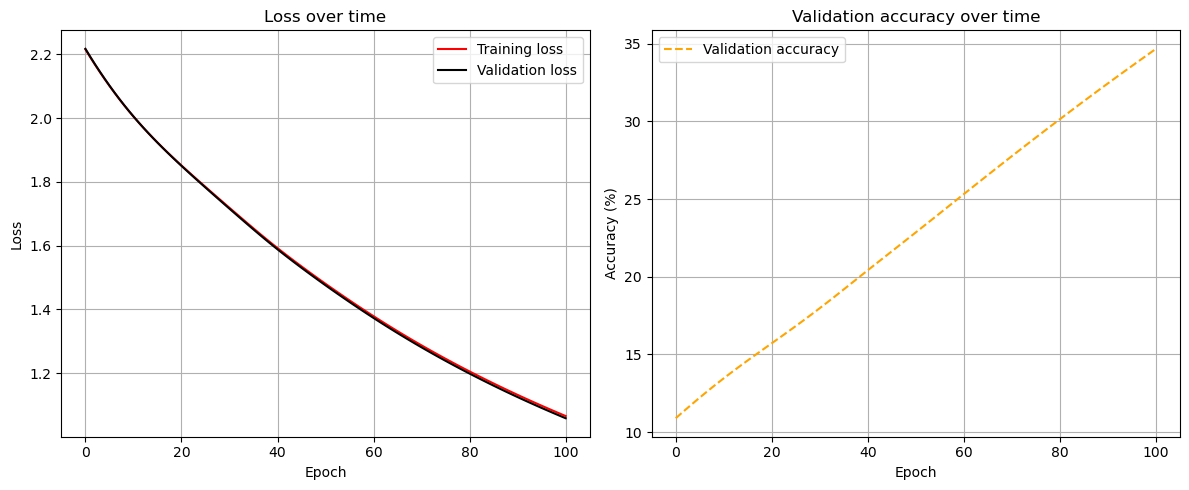

In [ ]:
x = np.linspace(0, len(training_loss_over_time), len(training_loss_over_time))
y1 = training_loss_over_time
y2 = validation_loss_over_time
y3 = validation_accuracy_over_time

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Loss over time")
axes[0].plot(x, y1, label="Training loss", linestyle="-", color="red")
axes[0].plot(x, y2, label="Validation loss", linestyle="-", color="black")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(bottom=0)
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("Validation accuracy over time")
axes[1].plot(x, y3, label="Validation accuracy", linestyle="--", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()